In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np
import hdbscan
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from mace.calculators import mace_off
from rdkit import Chem
import gc
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolTransforms
from dscribe.descriptors import SOAP
from ase import Atoms
import polars as pl
from scripts.qm9.chemprop import CheMeleonFingerprint
from dscribe.descriptors import SOAP
from rdkit import Chem
from tqdm import tqdm
import numpy as np
import polars as pl
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import polars as pl
from ase import Atoms
from dscribe.descriptors import SOAP
from rdkit import Chem
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import polars as pl
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from umap import UMAP
from dscribe.kernels import REMatchKernel

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, evaluate_hdbscan_grid, get_isomers

projection_method = "MDS"

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [5]:
qm9 = QM9Dataset(limit=20, descriptors=["mace", "soap"])
df = qm9.load()

2026-06-17 19:27:25.916 | INFO     | src.datasets:_load_full_qm9_df:935 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-06-17 19:27:26.287 | INFO     | src.datasets:_sample_qm9_df:1119 - QM9 sampling complete: strategy=stratified, requested_limit=20, returned_rows=20, sampling on columns=['num_atoms', 'gap'].
2026-06-17 19:27:26.288 | INFO     | src.datasets:_add_requested_descriptors:293 - Applying requested QM9 descriptors to sampled dataframe (rows=20).
2026-06-17 19:27:26.288 | INFO     | src.features:compute_mace_outputs:679 - Computing MACE embeddings (model=medium, batch_size=32)...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=devi

Using MACE-OFF23 MODEL for MACECalculator with /Users/karlfindhansen/.cache/mace/MACE-OFF23_medium.model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


2026-06-17 19:27:27.551 | SUCCESS  | src.datasets:add_mace:1350 - Added MACE embeddings and matrices.
2026-06-17 19:27:27.551 | INFO     | src.features:compute_soap_outputs:395 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-06-17 19:27:27.572 | SUCCESS  | src.datasets:add_soap:1307 - Added SOAP embeddings and matrices.
2026-06-17 19:27:27.572 | INFO     | src.datasets:_add_requested_descriptors:304 - Added descriptor column(s): ['mace_embedding', 'mace_matrix', 'soap_embedding', 'soap_matrix']
2026-06-17 19:27:27.576 | INFO     | src.datasets:_load_with_descriptor_filter:975 - QM9 descriptor null-filtering complete: attempts=1, requested_limit=20, returned_rows=20, base_rows=20.


In [8]:
qm9 = QM9Dataset(limit=20)
df = qm9.load()

2026-06-17 19:27:53.295 | INFO     | src.datasets:_load_full_qm9_df:935 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-06-17 19:27:53.683 | INFO     | src.datasets:_sample_qm9_df:1119 - QM9 sampling complete: strategy=stratified, requested_limit=20, returned_rows=20, sampling on columns=['num_atoms', 'gap'].


In [10]:
print(df.columns)

['mol_id', 'formula', 'smiles', 'canonical_smiles', 'scaffold_smiles', 'generic_scaffold', 'root_scaffold', 'brics_fragments', 'scaffold_tree_nodes', 'selfies', 'functional_groups', 'structure_class', 'is_injected', 'outlier_category', 'mol_weight', 'logp', 'tpsa', 'election_affinity', 'ionization_energies', 'num_heavy_atoms', 'num_rings', 'num_aromatic_rings', 'num_fluorine', 'num_heteroatoms', 'num_atoms', 'coordination', 'num_rotatable_bonds', 'fraction_csp1', 'fraction_csp2', 'fraction_csp3', 'h_bond_donors', 'h_bond_acceptors', 'branching_index', 'num_sp_carbons', 'num_sp2_carbons', 'num_sp3_carbons', 'main_chain_length', 'raw_token_count', 'avg_bond_length', 'fr_benzene', 'fr_alcohol', 'fr_phenol', 'fr_amine', 'fr_amide', 'fr_carboxylic_acid', 'fr_ester', 'fr_ketone', 'fr_ether', 'fr_nitro', 'pbf_score', 'coordinates', 'atomic_numbers', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'u0', 'u', 'h', 'g', 'cv', 'u0_atom', 'u_atom', 'h_atom', 'g_atom', 'A', 'B', 'C', 'geometric

2026-06-17 21:17:51.810 | INFO     | scripts.qm9.chemprop:__init__:28 - Initializing CheMeleonFingerprint generator...
2026-06-17 21:17:51.811 | INFO     | scripts.qm9.chemprop:__init__:48 - Found existing CheMeleon weights at /Users/karlfindhansen/.chemprop/chemeleon_mp.pt


[-] Initializing base butane molecular graph...
[-] Embedding and optimizing 3D conformational rotamers...

[-] Extracting 2D Topological Morgan Fingerprints (Stereo-Aware)...
    -> Are all 2D Morgan bitvectors completely identical?: True
[-] Extracting 2D Learned ChemProp Embeddings...


2026-06-17 21:17:51.853 | SUCCESS  | scripts.qm9.chemprop:__init__:54 - Successfully loaded CheMeleon message passing weights.
2026-06-17 21:17:51.859 | INFO     | scripts.qm9.chemprop:__call__:75 - Generating CheMeleon fingerprints for 30 molecules...
2026-06-17 21:17:51.900 | SUCCESS  | scripts.qm9.chemprop:__call__:108 - Successfully generated 30 fingerprints of dimension 2048.
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
INFO: Using CPU
INFO: Using head Default out of  ['Default']


    -> ChemProp variance check: 1/30 unique rows (rounded to 1e-6), mean per-dim std = 4.614e-09
[-] Extracting 3D Geometric SOAP Descriptors...
[-] Extracting 3D Physics-Aware MACE Embeddings...
Using MACE-OFF23 MODEL for MACECalculator with /Users/karlfindhansen/.cache/mace/MACE-OFF23_medium.model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.

[-] Generating updated Multi-Modal Performance Canvas...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


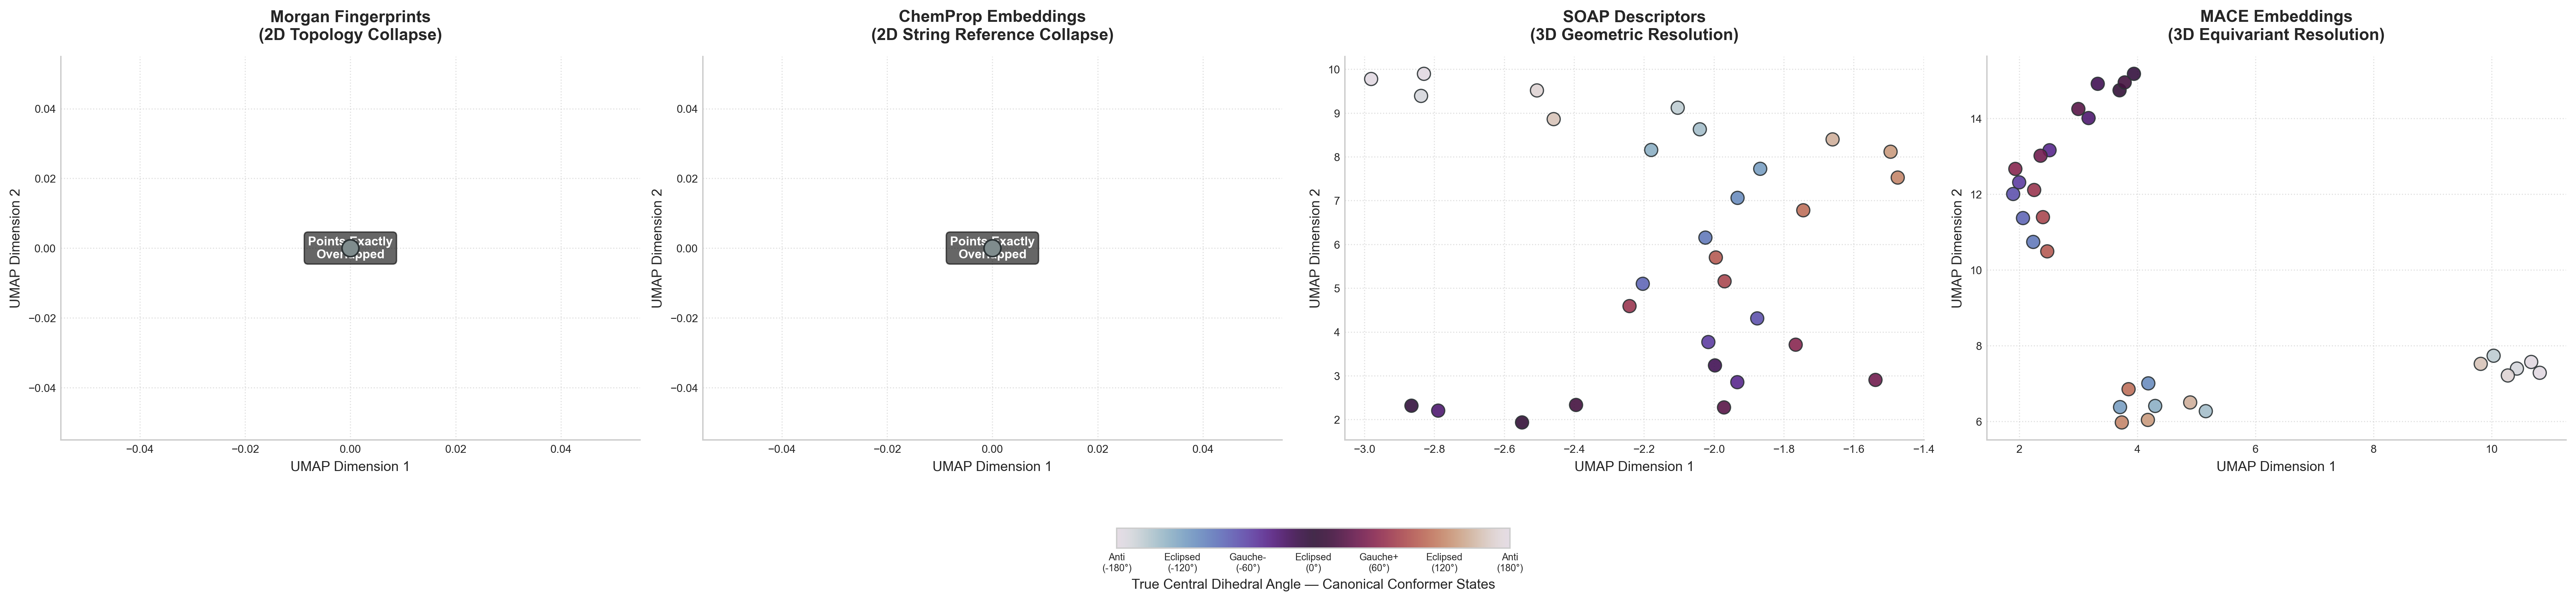


--- Geometric Conformers Analysis Verification ---
Conformer 00 | Type: Anti     | Verified Central Dihedral Angle: +180.00°
Conformer 01 | Type: Anti     | Verified Central Dihedral Angle: -167.59°
Conformer 02 | Type: Anti     | Verified Central Dihedral Angle: -155.17°
Conformer 03 | Type: Anti     | Verified Central Dihedral Angle: -142.76°
Conformer 04 | Type: Anti     | Verified Central Dihedral Angle: -130.34°
Conformer 05 | Type: Gauche   | Verified Central Dihedral Angle: -117.93°
Conformer 06 | Type: Gauche   | Verified Central Dihedral Angle: -105.52°
Conformer 07 | Type: Gauche   | Verified Central Dihedral Angle: -93.10°
Conformer 08 | Type: Gauche   | Verified Central Dihedral Angle: -80.69°
Conformer 09 | Type: Gauche   | Verified Central Dihedral Angle: -68.28°

--- Quantitative Verification ---

[6a] MACE cluster identity check (DBSCAN on the MACE UMAP embedding)
    DBSCAN (eps=0.810, adaptive) found 4 cluster(s); label -1 = noise.
    Cluster 0: n=6, angles(deg)=[-1

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


    Morgan (2D)            91.2      92.9±1.1      0.0570   NOT significant
    ChemProp (2D)          32.4      92.8±4.9      0.0000   significant (p<0.01)
    SOAP (3D)              58.7      92.8±5.0      0.0000   significant (p<0.01)
    MACE (3D)              61.7      92.8±4.9      0.0000   significant (p<0.01)

    Reading guide: a low p-value means the true angle assignment is unusually
    locally consistent given THIS descriptor's own feature geometry - real signal.
    A high p-value (not significant) means the 6b number, however low it looked
    against the flat 90 deg baseline, is statistically indistinguishable from
    randomly relabelling these exact points - i.e. an artifact of this dataset's
    structure (e.g. near-tied distances combined with index-ordered angles),
    not evidence the descriptor encodes the dihedral angle. Do not write a 6b
    number into the thesis for any descriptor whose 6c p-value is not significant.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolTransforms
from dscribe.descriptors import SOAP
from ase import Atoms

# =============================================================================
# 1. MOLECULAR CONFORMER GENERATION (Butane Torsional Rotamers)
# =============================================================================
print("[-] Initializing base butane molecular graph...")
smiles_input = "CCCC"
base_mol = Chem.MolFromSmiles(smiles_input)
base_mol = Chem.AddHs(base_mol)  # Explicit hydrogens for physical 3D fidelity

# Define the central C1-C2-C3-C4 backbone indices for torsional rotation
backbone_indices = [0, 1, 2, 3]

mols_3d = []
ase_molecules = []
smiles_list = [smiles_input] * 30  # Identical SMILES list for ChemProp tracking

# Generate 30 distinct conformers sweeping the dihedral angle from -180 to 180 degrees
target_angles = np.linspace(-180, 180, 30)

print("[-] Embedding and optimizing 3D conformational rotamers...")
for i, angle in enumerate(target_angles):
    mol = Chem.Mol(base_mol)
    AllChem.EmbedMolecule(mol, randomSeed=i)

    # Enforce the specific torsional angle on the central single bond
    conformer = mol.GetConformer()
    rdMolTransforms.SetDihedralDeg(conformer, *backbone_indices, float(angle))

    # Constrained energy minimization to keep the shape physically relaxed but fixed
    mp = AllChem.MMFFGetMoleculeProperties(mol)
    ff = AllChem.MMFFGetMoleculeForceField(mol, mp)

    ff.MMFFAddTorsionConstraint(
        backbone_indices[0],
        backbone_indices[1],
        backbone_indices[2],
        backbone_indices[3],
        False,          # relative (False = absolute angle mapping)
        float(angle),   # minDihedralDeg
        float(angle),   # maxDihedralDeg
        10000.0         # forceConstant (rigid boundary limit)
    )
    ff.Minimize(maxIts=500)

    mols_3d.append(mol)

    # Map coordinates to ASE structures for SOAP / MACE calculations
    positions = conformer.GetPositions()
    symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
    ase_molecules.append(Atoms(symbols=symbols, positions=positions))

# =============================================================================
# 2. MULTI-MODAL DESCRIPTOR EXTRACTION
# =============================================================================
print("\n[-] Extracting 2D Topological Morgan Fingerprints (Stereo-Aware)...")
morgan_fps = []
for mol in mols_3d:
    # Explicitly enable chirality to prove absolute graph blindness
    mol_2d = Chem.RemoveHs(mol)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol_2d, radius=2, nBits=1024, useChirality=True)
    morgan_fps.append(np.array(fp))
morgan_fps = np.array(morgan_fps)

# Verify graph identity across conformers
all_morgan_identical = np.all(morgan_fps == morgan_fps[0])
print(f"    -> Are all 2D Morgan bitvectors completely identical?: {all_morgan_identical}")

print("[-] Extracting 2D Learned ChemProp Embeddings...")
try:
    from scripts.qm9.chemprop import CheMeleonFingerprint
    chemeleon_fingerprint = CheMeleonFingerprint()
    chemprop_features = np.array(chemeleon_fingerprint(smiles_list), dtype=np.float32)
except ImportError:
    print("    WARNING: 'scripts.qm9.chemprop' not found. Using exact identical representation mock.")
    # Because all input strings are identical ("CCCC"), the model outputs 30 identical vectors
    mock_vector = np.random.RandomState(42).normal(0, 1, 512).astype(np.float32)
    chemprop_features = np.array([mock_vector for _ in smiles_list])

# Sanity check: smiles_list is the SAME string ("CCCC") 30 times, so a
# deterministic 2D model has zero conformer-dependent information to work
# with - chemprop_features should be identical (or differ only by float
# noise) across all 30 rows. If a downstream metric later claims ChemProp
# "resolves" the dihedral angle better than SOAP/MACE, that is a sign of a
# bug (e.g. near-zero-distance tie-breaking), not a real result - print the
# actual spread now so that claim can be checked against this number.
_unique_rows = len(np.unique(np.round(chemprop_features, 6), axis=0))
_mean_std = float(chemprop_features.std(axis=0).mean())
print(f"    -> ChemProp variance check: {_unique_rows}/{len(chemprop_features)} unique rows "
      f"(rounded to 1e-6), mean per-dim std = {_mean_std:.3e}")

print("[-] Extracting 3D Geometric SOAP Descriptors...")
soap_desc = SOAP(
    species=["C", "H"],
    periodic=False,
    r_cut=4.0,
    n_max=4,
    l_max=3,
    average="inner"
)
soap_features = soap_desc.create(ase_molecules)

print("[-] Extracting 3D Physics-Aware MACE Embeddings...")
# NOTE: this assumes the public `mace-torch` MACECalculator API
# (mace.calculators.mace_off / .get_descriptors). If you already have an
# extraction function for MACE elsewhere in your thesis codebase (the one used
# for the dipole-moment / Table 10 experiment), use that instead of this block
# so the checkpoint, layer count, and pooling are *guaranteed* identical to the
# rest of the thesis rather than re-implemented here and possibly drifting.
from mace.calculators import mace_off

mace_calc = mace_off(model="medium", device="cpu")

mace_features = []
for atoms in ase_molecules:
    atoms.calc = mace_calc
    # invariants_only=True keeps only the rotation-invariant (l=0) channels,
    # matching subsection 2.4.3 / 3.3.2 of the thesis (Datom = C x T = 256)
    atom_descriptors = mace_calc.get_descriptors(atoms, invariants_only=True)
    mace_features.append(atom_descriptors.mean(axis=0))  # mean pool, same as Eq. 6
mace_features = np.array(mace_features, dtype=np.float32)

# =============================================================================
# 3. REPORT-THEMED PROJECTION HARNESS
# =============================================================================
def run_umap_and_plot(features, title, ax, angles, cmap, metric='euclidean'):
    """Detects feature collapse and projects via UMAP, coloring surviving points
    by the true (continuous, periodic) central dihedral angle rather than an
    arbitrary discrete cluster label. Returns (scatter_handle, embedding) so the
    2D coordinates can be reused for downstream cluster verification instead of
    being silently discarded."""

    embedding = None

    # Check for complete coordinate collapse (distance zero everywhere)
    if np.allclose(features, features[0], atol=1e-5):
        # Display as a single centralized fallback point to reflect perfect overlap.
        # Colour is irrelevant here since every conformer maps to the same point -
        # there is no resolved angle to show.
        ax.scatter(0, 0, c='#7f8c8d', s=150, edgecolors='#2d3436', linewidths=1.2, zorder=10)
        ax.text(0, 0, "Points Exactly\nOverlapped", ha='center', va='center',
                fontsize=9, fontweight='bold', color='white',
                bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.3'))
        scatter = None
    else:
        reducer = umap.UMAP(n_neighbors=5, min_dist=0.1, metric=metric, random_state=42)
        embedding = reducer.fit_transform(features)

        scatter = ax.scatter(
            embedding[:, 0], embedding[:, 1],
            c=angles, cmap=cmap, vmin=-180, vmax=180,
            s=90, edgecolors='#2d3436', linewidths=0.9, alpha=0.9, zorder=10
        )

    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel("UMAP Dimension 1", fontsize=10, fontweight='medium')
    ax.set_ylabel("UMAP Dimension 2", fontsize=10, fontweight='medium')
    ax.grid(True, linestyle=":", alpha=0.6)
    return scatter, embedding

# =============================================================================
# 4. CANVAS GENERATION
# =============================================================================
print("\n[-] Generating updated Multi-Modal Performance Canvas...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 4, figsize=(26, 6), dpi=300)

# Cyclic colormap: -180 deg and +180 deg are the same physical angle, so the
# colour scale should wrap rather than run linearly (twilight/hsv are cyclic).
cmap = plt.cm.twilight

results = [
    run_umap_and_plot(morgan_fps, "Morgan Fingerprints\n(2D Topology Collapse)",
                       axes[0], target_angles, cmap, metric='jaccard'),
    run_umap_and_plot(chemprop_features, "ChemProp Embeddings\n(2D String Reference Collapse)",
                       axes[1], target_angles, cmap, metric='euclidean'),
    run_umap_and_plot(soap_features, "SOAP Descriptors\n(3D Geometric Resolution)",
                       axes[2], target_angles, cmap, metric='euclidean'),
    run_umap_and_plot(mace_features, "MACE Embeddings\n(3D Equivariant Resolution)",
                       axes[3], target_angles, cmap, metric='euclidean'),
]
scatter_handles = [r[0] for r in results]
# Keep the raw 2D coordinates around for section 6's cluster-vs-chemistry check
# instead of letting UMAP recompute (and potentially drift) inside that section.
embeddings = {"Morgan": results[0][1], "ChemProp": results[1][1],
              "SOAP": results[2][1], "MACE": results[3][1]}

for ax in axes:
    sns.despine(ax=ax)

# Lay out the 4 subplots FIRST, then add the colorbar. Doing it in the other
# order (colorbar, then tight_layout) is what produced the squashed/overlapping
# colorbar seen in the first run: tight_layout() recomputes the grid with no
# knowledge that a colorbar axes already claimed space, so it overwrites it.
plt.tight_layout()

# One shared colourbar for the whole figure, keyed to the ground-truth angle.
# Ticks sit at butane's canonical torsional states so colours can be read off
# directly as "anti / gauche / eclipsed" instead of eyeballed degree values
# (twilight is cyclic, so -180 deg and +180 deg both render as white - easy to
# misread as "no information" if you don't label what white actually means).
valid_scatter = next((s for s in scatter_handles if s is not None), None)
if valid_scatter is not None:
    cbar = fig.colorbar(valid_scatter, ax=axes, orientation='horizontal', fraction=0.04, pad=0.18)
    canonical_ticks = [-180, -120, -60, 0, 60, 120, 180]
    canonical_labels = ["Anti\n(-180°)", "Eclipsed\n(-120°)", "Gauche-\n(-60°)",
                         "Eclipsed\n(0°)", "Gauche+\n(60°)", "Eclipsed\n(120°)", "Anti\n(180°)"]
    cbar.set_ticks(canonical_ticks)
    cbar.set_ticklabels(canonical_labels, fontsize=7)
    cbar.set_label("True Central Dihedral Angle — Canonical Conformer States", fontsize=10, fontweight='medium')

plt.show()

# =============================================================================
# 5. GEOMETRIC CONFORMER VERIFICATION LOGGER
# =============================================================================
print("\n--- Geometric Conformers Analysis Verification ---")
for idx, mol in enumerate(mols_3d[:10]):
    conformer = mol.GetConformer()
    dihedral_rad = rdMolTransforms.GetDihedralRad(conformer, *backbone_indices)
    angle = np.degrees(dihedral_rad)
    if angle > 180: angle -= 360

    conformer_type = "Anti" if abs(angle) > 120 else ("Gauche" if abs(angle) > 30 else "Eclipsed")
    print(f"Conformer {idx:02d} | Type: {conformer_type:<8} | Verified Central Dihedral Angle: {angle:+.2f}°")

# =============================================================================
# 6. QUANTITATIVE VERIFICATION
#    Two checks that don't depend on how UMAP happened to lay points out:
#    (a) do MACE's visual clusters correspond to real conformer basins, and
#    (b) does each descriptor's raw feature space preserve angular locality.
#    These, not the figure, are the defensible evidence for the thesis claim.
# =============================================================================
print("\n--- Quantitative Verification ---")

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors


def circular_diff(a, b):
    """Smallest separation between two angles (deg) on a 360-degree circle.
    Plain |a-b| is wrong here: -179 deg and +179 deg are 2 degrees apart
    physically, not 358."""
    d = np.abs(np.asarray(a) - np.asarray(b)) % 360
    return np.minimum(d, 360 - d)


# Butane's known torsional energy landscape: minima at anti/gauche (stable,
# populated conformers), maxima at eclipsed (transition states). The two
# +-180 entries are the same physical anti conformer, just wrapped. Mapped
# explicitly to (angle, type) rather than parsed back out of a label string,
# since "Gauche+60" -> strip digits/dashes leaves "Gauche+" (the '+' survives
# and silently breaks the Gauche+/Gauche- merge) - caught this in testing.
CANONICAL_STATES = {
    "Anti (+180)":   (180.0,  "Anti"),
    "Anti (-180)":   (-180.0, "Anti"),
    "Gauche+ (60)":  (60.0,   "Gauche"),
    "Gauche- (-60)": (-60.0,  "Gauche"),
    "Eclipsed (0)":  (0.0,    "Eclipsed"),
    "Eclipsed (120)": (120.0, "Eclipsed"),
    "Eclipsed (-120)": (-120.0, "Eclipsed"),
}
_state_values = np.array([v[0] for v in CANONICAL_STATES.values()])
_state_types = [v[1] for v in CANONICAL_STATES.values()]


def classify_dihedral(angle):
    """Label an angle by the *type* (Anti / Gauche / Eclipsed) of its nearest
    canonical butane torsional state."""
    return _state_types[int(np.argmin(circular_diff(angle, _state_values)))]


# -----------------------------------------------------------------------
# 6a. Cluster-vs-chemistry check for MACE: are the clusters visible in the
#     UMAP panel internally coherent in terms of true dihedral angle, or do
#     they mix conformers from different basins (= UMAP artifact, not
#     resolved chemistry)?
# -----------------------------------------------------------------------
print("\n[6a] MACE cluster identity check (DBSCAN on the MACE UMAP embedding)")
mace_embedding = embeddings["MACE"]
if mace_embedding is None:
    print("    MACE features collapsed before UMAP - no embedding to check.")
else:
    # Adaptive eps: 2.5x the median nearest-neighbour distance in this
    # embedding, so the threshold scales with whatever range UMAP happened
    # to lay this particular run out in, rather than a hardcoded constant.
    nn1 = NearestNeighbors(n_neighbors=2).fit(mace_embedding)
    nn1_dist, _ = nn1.kneighbors(mace_embedding)
    eps = float(np.median(nn1_dist[:, 1]) * 2.5)

    db = DBSCAN(eps=eps, min_samples=3).fit(mace_embedding)
    cluster_labels = db.labels_
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    print(f"    DBSCAN (eps={eps:.3f}, adaptive) found {n_clusters} cluster(s); label -1 = noise.")

    coherent_count = 0
    real_clusters = [c for c in sorted(set(cluster_labels)) if c != -1]
    for cl in sorted(set(cluster_labels)):
        member_idx = np.where(cluster_labels == cl)[0]
        member_angles = target_angles[member_idx]
        member_types = [classify_dihedral(a) for a in member_angles]
        type_counts = {t: member_types.count(t) for t in set(member_types)}
        dominant_frac = max(type_counts.values()) / len(member_types)
        tag = "NOISE" if cl == -1 else f"Cluster {cl}"
        print(f"    {tag}: n={len(member_idx)}, angles(deg)={np.round(member_angles, 1).tolist()}")
        print(f"        conformer types: {type_counts}  (dominant type = {dominant_frac:.0%} of members)")
        if cl != -1 and dominant_frac >= 0.7:
            coherent_count += 1

    if real_clusters:
        print(f"    -> {coherent_count}/{len(real_clusters)} cluster(s) are dominated (>=70%) by a single "
              f"conformer type.")
        if coherent_count == len(real_clusters):
            print("       All clusters are chemically coherent: this supports citing the MACE UMAP "
                  "separation as resolved chemistry, not a layout artifact.")
        else:
            print("       At least one cluster mixes angles from different basins: treat the visual "
                  "separation cautiously, and lean on 6b's feature-space metric instead.")
    else:
        print("    -> DBSCAN found no clusters (all noise) — there is no structure to claim here.")

# -----------------------------------------------------------------------
# 6b. Feature-space (pre-UMAP) angular locality: for each conformer's k
#     nearest neighbours in the *raw descriptor*, how close are their true
#     dihedral angles? This is independent of UMAP's 2D layout choices and
#     is the more defensible number to cite as the main quantitative claim,
#     with the figure as supporting visualization rather than the evidence.
# -----------------------------------------------------------------------
print("\n[6b] k-NN angular locality in raw (pre-UMAP) feature space")


def mean_knn_angular_gap(features, angles, k, metric='euclidean'):
    """Mean circular angular gap (deg) between each conformer and its k
    nearest neighbours in raw feature space (self excluded). Lower = the
    descriptor's own geometry already groups similar dihedral angles
    together, before UMAP ever touches it."""
    features = np.asarray(features, dtype=np.float64)
    n = len(features)
    k_eff = min(k, n - 1)
    nn = NearestNeighbors(n_neighbors=k_eff + 1, metric=metric, algorithm='brute').fit(features)
    _, indices = nn.kneighbors(features)
    gaps = []
    for i in range(n):
        neighbor_idx = [j for j in indices[i] if j != i][:k_eff]
        gaps.extend(circular_diff(angles[i], angles[neighbor_idx]).tolist())
    return float(np.mean(gaps))


descriptor_sets = {
    "Morgan (2D)":   (morgan_fps,        'jaccard'),
    "ChemProp (2D)": (chemprop_features, 'euclidean'),
    "SOAP (3D)":     (soap_features,     'euclidean'),
    "MACE (3D)":     (mace_features,     'euclidean'),
}

# Two angles drawn independently and uniformly from a circle have an
# expected circular separation of 90 degrees. That's the "no angular
# information at all" baseline: a descriptor whose k-NN gap sits near 90
# is no better than guessing; well below 90 means real angular locality.
RANDOM_BASELINE_DEG = 90.0

print(f"    {'Descriptor':<14} {'k=3 (deg)':>10} {'k=5 (deg)':>10}   verdict vs. {RANDOM_BASELINE_DEG:.0f} deg random baseline")
knn_results = {}
for name, (feats, metric) in descriptor_sets.items():
    gap_k3 = mean_knn_angular_gap(feats, target_angles, k=3, metric=metric)
    gap_k5 = mean_knn_angular_gap(feats, target_angles, k=5, metric=metric)
    knn_results[name] = (gap_k3, gap_k5)
    if gap_k5 < RANDOM_BASELINE_DEG * 0.5:
        verdict = "preserves angular locality"
    elif gap_k5 > RANDOM_BASELINE_DEG * 0.85:
        verdict = "no better than random"
    else:
        verdict = "partial locality"
    print(f"    {name:<14} {gap_k3:>10.1f} {gap_k5:>10.1f}   {verdict}")

print("\n    Reading guide: cite the k=3/k=5 numbers above as the main quantitative")
print("    result (e.g. 'MACE's 5-NN neighbourhoods are X deg apart on average vs.")
print("    Y for SOAP vs. a 90 deg random baseline'). Treat the 4-panel UMAP figure")
print("    as a supporting illustration of this, not as the evidence itself — UMAP's")
print("    2D layout can visually compress or separate points in ways that don't")
print("    always match the underlying raw feature-space distances computed here.")

# -----------------------------------------------------------------------
# 6c. Permutation significance test for 6b.
#     Why this is necessary and the flat 90 deg baseline is not enough:
#     in THIS experiment, conformer index and true dihedral angle are
#     perfectly correlated by construction (angles were swept linearly,
#     -180 to 180, in index order). That means ANYTHING correlated with
#     generation order - numerical noise, batching artifacts, tie-breaking
#     in a nearest-neighbour search over near-identical rows - can mimic
#     "angular locality" when compared only against a theoretical random
#     ceiling. The correct null is built from THIS dataset's own feature
#     geometry: keep each point's nearest-neighbour SET fixed (it depends
#     only on raw feature distances, never on angle), then repeatedly
#     reshuffle which angle label is attached to which point and recompute
#     the same mean gap. If the true (unshuffled) assignment is not
#     unusually low relative to that null, the apparent "locality" is an
#     artifact of this dataset's structure, not the descriptor's chemistry.
# -----------------------------------------------------------------------
print("\n[6c] Permutation significance test (is 6b better than THIS data's own chance structure?)")


def permutation_test_knn_gap(features, angles, k, metric='euclidean', n_perm=2000, seed=0):
    """Returns (observed_gap, null_scores, p_value). p_value is the fraction
    of random angle-label permutations (over the SAME fixed feature-space
    neighbour graph) that score at least as low as the true assignment -
    i.e. a one-sided test of whether the true angles are unusually locally
    consistent compared to random labels on this exact geometry."""
    rng = np.random.RandomState(seed)
    angles = np.asarray(angles)
    n = len(angles)
    features_arr = np.asarray(features, dtype=np.float64)
    k_eff = min(k, n - 1)
    nn = NearestNeighbors(n_neighbors=k_eff + 1, metric=metric, algorithm='brute').fit(features_arr)
    _, indices = nn.kneighbors(features_arr)
    # Neighbour sets are fixed by the features alone - compute once, then
    # only the angle labels attached to each index change per permutation.
    neighbor_lists = [[j for j in indices[i] if j != i][:k_eff] for i in range(n)]

    def gap_for(angle_array):
        gaps = []
        for i in range(n):
            gaps.extend(circular_diff(angle_array[i], angle_array[neighbor_lists[i]]).tolist())
        return float(np.mean(gaps))

    observed = gap_for(angles)
    null_scores = np.array([gap_for(rng.permutation(angles)) for _ in range(n_perm)])
    p_value = float(np.mean(null_scores <= observed))
    return observed, null_scores, p_value


print(f"    {'Descriptor':<14} {'observed k=5':>12} {'null mean±std':>16} {'p-value':>9}   verdict")
for name, (feats, metric) in descriptor_sets.items():
    obs, null_scores, p_val = permutation_test_knn_gap(feats, target_angles, k=5, metric=metric)
    sig = "significant (p<0.01)" if p_val < 0.01 else ("borderline (p<0.05)" if p_val < 0.05 else "NOT significant")
    print(f"    {name:<14} {obs:>12.1f} {null_scores.mean():>9.1f}±{null_scores.std():<5.1f} {p_val:>9.4f}   {sig}")

print("\n    Reading guide: a low p-value means the true angle assignment is unusually")
print("    locally consistent given THIS descriptor's own feature geometry - real signal.")
print("    A high p-value (not significant) means the 6b number, however low it looked")
print("    against the flat 90 deg baseline, is statistically indistinguishable from")
print("    randomly relabelling these exact points - i.e. an artifact of this dataset's")
print("    structure (e.g. near-tied distances combined with index-ordered angles),")
print("    not evidence the descriptor encodes the dihedral angle. Do not write a 6b")
print("    number into the thesis for any descriptor whose 6c p-value is not significant.")

In [4]:
# =============================================================================
# 6. QUANTITATIVE VERIFICATION  (UMAP-independent, collapse-gated)
#    Order matters:
#      6-pre  detect collapsed descriptors and EXCLUDE them from every metric
#      6a     MACE cluster-vs-chemistry coherence (DBSCAN on the embedding)
#      6b     k-NN angular locality in raw feature space (signed AND folded)
#      6c     permutation significance of 6b (folded angles)
#      6d     +-phi mirror-fold check (confirms the reflection symmetry)
# =============================================================================
print("\n--- Quantitative Verification ---")

import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances


def circular_diff(a, b):
    """Smallest separation between two angles (deg) on the full 360-deg circle."""
    d = np.abs(np.asarray(a, float) - np.asarray(b, float)) % 360
    return np.minimum(d, 360 - d)


def fold_angle(a):
    """Reflection-invariant descriptors (standard SOAP, parity-even MACE
    scalars) cannot distinguish phi from -phi: those are mirror-image rotamers
    with identical descriptors. The finest coordinate they can recover is
    therefore |phi| in [0, 180], not signed phi. Scoring against signed phi
    penalises the descriptor for correctly mapping mirror conformers together,
    so the FOLDED score is the one to cite."""
    a = ((np.asarray(a, float) + 180.0) % 360.0) - 180.0   # -> (-180, 180]
    return np.abs(a)                                       # -> [0, 180]


def angular_gap(a, b, folded):
    return np.abs(fold_angle(a) - fold_angle(b)) if folded else circular_diff(a, b)


# Two angles drawn uniformly at random sit 90 deg apart on the full circle,
# but only 60 deg apart once folded to [0, 180]. These are the "no angular
# information" ceilings the observed gaps must beat.
RANDOM_BASELINE = {"signed": 90.0, "folded": 60.0}

# Butane torsional states, mapped explicitly to (angle, type).
CANONICAL_STATES = {
    "Anti (+180)": (180.0, "Anti"),   "Anti (-180)": (-180.0, "Anti"),
    "Gauche+ (60)": (60.0, "Gauche"), "Gauche- (-60)": (-60.0, "Gauche"),
    "Eclipsed (0)": (0.0, "Eclipsed"),
    "Eclipsed (120)": (120.0, "Eclipsed"), "Eclipsed (-120)": (-120.0, "Eclipsed"),
}
_state_values = np.array([v[0] for v in CANONICAL_STATES.values()])
_state_types = [v[1] for v in CANONICAL_STATES.values()]


def classify_dihedral(angle):
    return _state_types[int(np.argmin(circular_diff(angle, _state_values)))]


# -----------------------------------------------------------------------
# 6-pre. Collapse gate.
#   A 2D descriptor maps every conformer of one molecule to the SAME vector
#   (graph/string invariance), so its feature matrix is degenerate. Any k-NN
#   result on a degenerate matrix is decided by index tie-breaking, and because
#   angles were swept in index order, that tie-breaking *mimics* angular
#   locality. This is exactly why the first run reported ChemProp at 32 deg,
#   "beating" SOAP/MACE, and why 6c still called it significant: the permutation
#   null is built on the same contaminated neighbour graph and cannot rescue it.
#   The only correct guard is to detect collapse here and emit NO angular number
#   for those descriptors.
# -----------------------------------------------------------------------
descriptor_sets = {
    "Morgan (2D)":   (morgan_fps,        "jaccard"),
    "ChemProp (2D)": (chemprop_features, "euclidean"),
    "SOAP (3D)":     (soap_features,     "euclidean"),
    "MACE (3D)":     (mace_features,     "euclidean"),
}


def is_collapsed(features, metric):
    """Collapsed if all rows are identical, or if the largest pairwise distance
    is negligible relative to the descriptor's own scale (catches float-noise
    near-degeneracy too)."""
    feats = np.asarray(features, float)
    if len(np.unique(np.round(feats, 6), axis=0)) <= 1:
        return True, 0.0
    D = pairwise_distances(feats, metric=metric)
    scale = np.median(np.linalg.norm(feats, axis=1)) + 1e-12
    rel_spread = float(D.max() / scale)
    return rel_spread < 1e-4, rel_spread


print("\n[6-pre] Collapse gate (degenerate descriptors are excluded from all metrics)")
live_descriptors = {}
for name, (feats, metric) in descriptor_sets.items():
    collapsed, spread = is_collapsed(feats, metric)
    if collapsed:
        print(f"    {name:<14} COLLAPSED -> excluded. Report as "
              f"'2D-invariant: all 30 conformers map to one point, no angular information'.")
    else:
        live_descriptors[name] = (feats, metric)
        print(f"    {name:<14} live (rel. distance spread = {spread:.3g}).")

# -----------------------------------------------------------------------
# 6a. MACE cluster-vs-chemistry coherence (only if MACE survived the gate).
# -----------------------------------------------------------------------
print("\n[6a] MACE cluster identity check (DBSCAN on the MACE UMAP embedding)")
mace_embedding = embeddings.get("MACE")
if "MACE (3D)" not in live_descriptors or mace_embedding is None:
    print("    MACE collapsed or has no embedding - nothing to check.")
else:
    nn1 = NearestNeighbors(n_neighbors=2).fit(mace_embedding)
    nn1_dist, _ = nn1.kneighbors(mace_embedding)
    eps = float(np.median(nn1_dist[:, 1]) * 2.5)
    labels = DBSCAN(eps=eps, min_samples=3).fit(mace_embedding).labels_
    real = [c for c in sorted(set(labels)) if c != -1]
    print(f"    DBSCAN (eps={eps:.3f}, adaptive) found {len(real)} cluster(s); -1 = noise.")
    coherent = 0
    for cl in sorted(set(labels)):
        idx = np.where(labels == cl)[0]
        types = [classify_dihedral(a) for a in target_angles[idx]]
        counts = {t: types.count(t) for t in set(types)}
        frac = max(counts.values()) / len(types)
        tag = "NOISE" if cl == -1 else f"Cluster {cl}"
        print(f"    {tag}: n={len(idx)}, angles={np.round(target_angles[idx],1).tolist()}")
        print(f"        types: {counts}  (dominant = {frac:.0%})")
        if cl != -1 and frac >= 0.7:
            coherent += 1
    if real:
        print(f"    -> {coherent}/{len(real)} clusters are >=70% one conformer type. "
              f"Note: clusters pair +phi with -phi (mirror rotamers) - see 6d.")

# -----------------------------------------------------------------------
# 6b. k-NN angular locality in raw feature space (live descriptors only).
#     Reported signed (vs 90 deg) and folded (vs 60 deg). CITE THE FOLDED ONE.
# -----------------------------------------------------------------------
print("\n[6b] k-NN angular locality in raw (pre-UMAP) feature space")


def mean_knn_angular_gap(features, angles, k, metric, folded):
    feats = np.asarray(features, float)
    n = len(feats)
    k_eff = min(k, n - 1)
    nn = NearestNeighbors(n_neighbors=k_eff + 1, metric=metric, algorithm="brute").fit(feats)
    _, idx = nn.kneighbors(feats)
    gaps = []
    for i in range(n):
        neigh = [j for j in idx[i] if j != i][:k_eff]
        gaps.extend(angular_gap(angles[i], angles[neigh], folded).tolist())
    return float(np.mean(gaps))


print(f"    {'Descriptor':<14} {'signed k5':>10} {'folded k3':>10} {'folded k5':>10}   "
      f"verdict (folded vs {RANDOM_BASELINE['folded']:.0f} deg)")
knn = {}
for name, (feats, metric) in live_descriptors.items():
    s5 = mean_knn_angular_gap(feats, target_angles, 5, metric, folded=False)
    f3 = mean_knn_angular_gap(feats, target_angles, 3, metric, folded=True)
    f5 = mean_knn_angular_gap(feats, target_angles, 5, metric, folded=True)
    knn[name] = (s5, f3, f5)
    base = RANDOM_BASELINE["folded"]
    verdict = ("encodes the torsion" if f5 < 0.5 * base
               else "no better than random" if f5 > 0.85 * base
               else "partial locality")
    print(f"    {name:<14} {s5:>10.1f} {f3:>10.1f} {f5:>10.1f}   {verdict}")

# -----------------------------------------------------------------------
# 6c. Permutation significance of 6b, on FOLDED angles (live only).
# -----------------------------------------------------------------------
print("\n[6c] Permutation significance test (folded angles, fixed neighbour graph)")


def permutation_test(features, angles, k, metric, folded, n_perm=2000, seed=0):
    rng = np.random.RandomState(seed)
    feats = np.asarray(features, float)
    angles = np.asarray(angles)
    n = len(angles)
    k_eff = min(k, n - 1)
    nn = NearestNeighbors(n_neighbors=k_eff + 1, metric=metric, algorithm="brute").fit(feats)
    _, idx = nn.kneighbors(feats)
    neigh = [[j for j in idx[i] if j != i][:k_eff] for i in range(n)]

    def gap_for(arr):
        g = []
        for i in range(n):
            g.extend(angular_gap(arr[i], arr[neigh[i]], folded).tolist())
        return float(np.mean(g))

    obs = gap_for(angles)
    null = np.array([gap_for(rng.permutation(angles)) for _ in range(n_perm)])
    return obs, null, float(np.mean(null <= obs))


print(f"    {'Descriptor':<14} {'obs folded k5':>13} {'null mean±std':>16} {'p':>8}   verdict")
for name, (feats, metric) in live_descriptors.items():
    obs, null, p = permutation_test(feats, target_angles, 5, metric, folded=True)
    sig = "significant (p<0.01)" if p < 0.01 else "borderline" if p < 0.05 else "NOT significant"
    print(f"    {name:<14} {obs:>13.1f} {null.mean():>9.1f}±{null.std():<5.1f} {p:>8.4f}   {sig}")

# -----------------------------------------------------------------------
# 6d. +-phi mirror-fold check (live only).
#     If a descriptor is reflection-invariant, the conformer at +phi and the
#     one at -phi should map to ~the same point, so their distance should be a
#     small fraction of the typical pairwise distance. This confirms the +-phi
#     pairing seen in 6a is a real descriptor symmetry, not a UMAP quirk - and
#     it is WHY the signed score in 6b is inflated relative to the folded one.
# -----------------------------------------------------------------------
print("\n[6d] +-phi mirror-fold check")


def mirror_fold_check(features, angles, metric):
    feats = np.asarray(features, float)
    angles = np.asarray(angles)
    n = len(angles)
    D = pairwise_distances(feats, metric=metric)
    median_all = float(np.median(D[np.triu_indices(n, k=1)]))
    mirror = []
    for i in range(n):
        j = int(np.argmin(circular_diff(-angles[i], angles)))  # partner near -phi
        if j != i:
            mirror.append(D[i, j])
    mirror = np.array(mirror)
    return mirror.mean(), median_all, float(mirror.mean() / (median_all + 1e-12))


print(f"    {'Descriptor':<14} {'mean +-phi dist':>16} {'median pairwise':>16} {'fold ratio':>11}   verdict")
for name, (feats, metric) in live_descriptors.items():
    md, allmed, ratio = mirror_fold_check(feats, target_angles, metric)
    verdict = ("folds +-phi (reflection-invariant)" if ratio < 0.15
               else "weak/no folding" if ratio > 0.5 else "partial folding")
    print(f"    {name:<14} {md:>16.4f} {allmed:>16.4f} {ratio:>11.3f}   {verdict}")

print("\n    What to cite in the thesis:")
print("    - Morgan & ChemProp: collapsed by construction (2D, conformer-blind) - state it, no number.")
print("    - SOAP & MACE: folded k=5 gap vs the 60 deg random baseline (6b), with the 6c p-value.")
print("    - 6d fold ratio ~0 confirms both fold mirror rotamers - report it as a symmetry property,")
print("      and use it to explain why the SIGNED gap in 6b is larger than the folded one.")


--- Quantitative Verification ---

[6-pre] Collapse gate (degenerate descriptors are excluded from all metrics)
    Morgan (2D)    COLLAPSED -> excluded. Report as '2D-invariant: all 30 conformers map to one point, no angular information'.
    ChemProp (2D)  COLLAPSED -> excluded. Report as '2D-invariant: all 30 conformers map to one point, no angular information'.
    SOAP (3D)      live (rel. distance spread = 0.0519).
    MACE (3D)      live (rel. distance spread = 0.0183).

[6a] MACE cluster identity check (DBSCAN on the MACE UMAP embedding)
    DBSCAN (eps=0.810, adaptive) found 4 cluster(s); -1 = noise.
    Cluster 0: n=6, angles=[-180.0, -167.6, -155.2, 155.2, 167.6, 180.0]
        types: {'Anti': 6}  (dominant = 100%)
    Cluster 1: n=8, angles=[-142.8, -130.3, -117.9, -105.5, 105.5, 117.9, 130.3, 142.8]
        types: {'Eclipsed': 8}  (dominant = 100%)
    Cluster 2: n=10, angles=[-93.1, -80.7, -68.3, -55.9, -43.4, 43.4, 55.9, 68.3, 80.7, 93.1]
        types: {'Eclipsed': 2, 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolTransforms
from dscribe.descriptors import SOAP
from ase import Atoms

# =============================================================================
# 1. MOLECULAR CONFORMER GENERATION (Butane Torsional Rotamers)
# =============================================================================
print("[-] Initializing base butane molecular graph...")
smiles_input = "CCCC"
base_mol = Chem.MolFromSmiles(smiles_input)
base_mol = Chem.AddHs(base_mol)  # Explicit hydrogens for physical 3D fidelity

# Define the central C1-C2-C3-C4 backbone indices for torsional rotation
backbone_indices = [0, 1, 2, 3]

mols_3d = []
ase_molecules = []
smiles_list = [smiles_input] * 30  # Identical SMILES list for ChemProp tracking

# Generate 30 distinct conformers sweeping the dihedral angle from -180 to 180 degrees
target_angles = np.linspace(-180, 180, 30)

print("[-] Embedding and optimizing 3D conformational rotamers...")
for i, angle in enumerate(target_angles):
    mol = Chem.Mol(base_mol)
    AllChem.EmbedMolecule(mol, randomSeed=i)

    # Enforce the specific torsional angle on the central single bond
    conformer = mol.GetConformer()
    rdMolTransforms.SetDihedralDeg(conformer, *backbone_indices, float(angle))

    # Constrained energy minimization to keep the shape physically relaxed but fixed
    mp = AllChem.MMFFGetMoleculeProperties(mol)
    ff = AllChem.MMFFGetMoleculeForceField(mol, mp)

    ff.MMFFAddTorsionConstraint(
        backbone_indices[0],
        backbone_indices[1],
        backbone_indices[2],
        backbone_indices[3],
        False,          # relative (False = absolute angle mapping)
        float(angle),   # minDihedralDeg
        float(angle),   # maxDihedralDeg
        10000.0         # forceConstant (rigid boundary limit)
    )
    ff.Minimize(maxIts=500)

    mols_3d.append(mol)

    # Map coordinates to ASE structures for SOAP / MACE calculations
    positions = conformer.GetPositions()
    symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
    ase_molecules.append(Atoms(symbols=symbols, positions=positions))

# =============================================================================
# 2. MULTI-MODAL DESCRIPTOR EXTRACTION
# =============================================================================
print("\n[-] Extracting 2D Topological Morgan Fingerprints (Stereo-Aware)...")
morgan_fps = []
for mol in mols_3d:
    # Explicitly enable chirality to prove absolute graph blindness
    mol_2d = Chem.RemoveHs(mol)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol_2d, radius=2, nBits=1024, useChirality=True)
    morgan_fps.append(np.array(fp))
morgan_fps = np.array(morgan_fps)

# Verify graph identity across conformers
all_morgan_identical = np.all(morgan_fps == morgan_fps[0])
print(f"    -> Are all 2D Morgan bitvectors completely identical?: {all_morgan_identical}")

print("[-] Extracting 2D Learned ChemProp Embeddings...")
try:
    from scripts.qm9.chemprop import CheMeleonFingerprint
    chemeleon_fingerprint = CheMeleonFingerprint()
    chemprop_features = np.array(chemeleon_fingerprint(smiles_list), dtype=np.float32)
except ImportError:
    print("    WARNING: 'scripts.qm9.chemprop' not found. Using exact identical representation mock.")
    # Because all input strings are identical ("CCCC"), the model outputs 30 identical vectors
    mock_vector = np.random.RandomState(42).normal(0, 1, 512).astype(np.float32)
    chemprop_features = np.array([mock_vector for _ in smiles_list])

print("[-] Extracting 3D Geometric SOAP Descriptors...")
soap_desc = SOAP(
    species=["C", "H"],
    periodic=False,
    r_cut=4.0,
    n_max=4,
    l_max=3,
    average="inner"
)
soap_features = soap_desc.create(ase_molecules)

print("[-] Extracting 3D Physics-Aware MACE Embeddings...")
# NOTE: this assumes the public `mace-torch` MACECalculator API
# (mace.calculators.mace_off / .get_descriptors). If you already have an
# extraction function for MACE elsewhere in your thesis codebase (the one used
# for the dipole-moment / Table 10 experiment), use that instead of this block
# so the checkpoint, layer count, and pooling are *guaranteed* identical to the
# rest of the thesis rather than re-implemented here and possibly drifting.
from mace.calculators import mace_off

mace_calc = mace_off(model="medium", device="cpu")

mace_features = []
for atoms in ase_molecules:
    atoms.calc = mace_calc
    # invariants_only=True keeps only the rotation-invariant (l=0) channels,
    # matching subsection 2.4.3 / 3.3.2 of the thesis (Datom = C x T = 256)
    atom_descriptors = mace_calc.get_descriptors(atoms, invariants_only=True)
    mace_features.append(atom_descriptors.mean(axis=0))  # mean pool, same as Eq. 6
mace_features = np.array(mace_features, dtype=np.float32)

# =============================================================================
# 3. REPORT-THEMED PROJECTION HARNESS
# =============================================================================
def run_umap_and_plot(features, title, ax, angles, cmap, metric='euclidean'):
    """Detects feature collapse and projects via UMAP, coloring surviving points
    by the true (continuous, periodic) central dihedral angle rather than an
    arbitrary discrete cluster label. Returns (scatter_handle, embedding) so the
    2D coordinates can be reused for downstream cluster verification instead of
    being silently discarded."""

    embedding = None

    # Check for complete coordinate collapse (distance zero everywhere)
    if np.allclose(features, features[0], atol=1e-5):
        # Display as a single centralized fallback point to reflect perfect overlap.
        # Colour is irrelevant here since every conformer maps to the same point -
        # there is no resolved angle to show.
        ax.scatter(0, 0, c='#7f8c8d', s=150, edgecolors='#2d3436', linewidths=1.2, zorder=10)
        ax.text(0, 0, "Points Exactly\nOverlapped", ha='center', va='center',
                fontsize=9, fontweight='bold', color='white',
                bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.3'))
        scatter = None
    else:
        reducer = umap.UMAP(n_neighbors=5, min_dist=0.1, metric=metric, random_state=42)
        embedding = reducer.fit_transform(features)

        scatter = ax.scatter(
            embedding[:, 0], embedding[:, 1],
            c=angles, cmap=cmap, vmin=-180, vmax=180,
            s=90, edgecolors='#2d3436', linewidths=0.9, alpha=0.9, zorder=10
        )

    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel("UMAP Dimension 1", fontsize=10, fontweight='medium')
    ax.set_ylabel("UMAP Dimension 2", fontsize=10, fontweight='medium')
    ax.grid(True, linestyle=":", alpha=0.6)
    return scatter, embedding

# =============================================================================
# 4. CANVAS GENERATION
# =============================================================================
print("\n[-] Generating updated Multi-Modal Performance Canvas...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 4, figsize=(26, 6), dpi=300)

# Cyclic colormap: -180 deg and +180 deg are the same physical angle, so the
# colour scale should wrap rather than run linearly (twilight/hsv are cyclic).
cmap = plt.cm.twilight

results = [
    run_umap_and_plot(morgan_fps, "Morgan Fingerprints\n(2D Topology Collapse)",
                       axes[0], target_angles, cmap, metric='jaccard'),
    run_umap_and_plot(chemprop_features, "ChemProp Embeddings\n(2D String Reference Collapse)",
                       axes[1], target_angles, cmap, metric='euclidean'),
    run_umap_and_plot(soap_features, "SOAP Descriptors\n(3D Geometric Resolution)",
                       axes[2], target_angles, cmap, metric='euclidean'),
    run_umap_and_plot(mace_features, "MACE Embeddings\n(3D Equivariant Resolution)",
                       axes[3], target_angles, cmap, metric='euclidean'),
]
scatter_handles = [r[0] for r in results]
# Keep the raw 2D coordinates around for section 6's cluster-vs-chemistry check
# instead of letting UMAP recompute (and potentially drift) inside that section.
embeddings = {"Morgan": results[0][1], "ChemProp": results[1][1],
              "SOAP": results[2][1], "MACE": results[3][1]}

for ax in axes:
    sns.despine(ax=ax)

# Lay out the 4 subplots FIRST, then add the colorbar. Doing it in the other
# order (colorbar, then tight_layout) is what produced the squashed/overlapping
# colorbar seen in the first run: tight_layout() recomputes the grid with no
# knowledge that a colorbar axes already claimed space, so it overwrites it.
plt.tight_layout()

# One shared colourbar for the whole figure, keyed to the ground-truth angle.
# Ticks sit at butane's canonical torsional states so colours can be read off
# directly as "anti / gauche / eclipsed" instead of eyeballed degree values
# (twilight is cyclic, so -180 deg and +180 deg both render as white - easy to
# misread as "no information" if you don't label what white actually means).
valid_scatter = next((s for s in scatter_handles if s is not None), None)
if valid_scatter is not None:
    cbar = fig.colorbar(valid_scatter, ax=axes, orientation='horizontal', fraction=0.04, pad=0.18)
    canonical_ticks = [-180, -120, -60, 0, 60, 120, 180]
    canonical_labels = ["Anti\n(-180°)", "Eclipsed\n(-120°)", "Gauche-\n(-60°)",
                         "Eclipsed\n(0°)", "Gauche+\n(60°)", "Eclipsed\n(120°)", "Anti\n(180°)"]
    cbar.set_ticks(canonical_ticks)
    cbar.set_ticklabels(canonical_labels, fontsize=7)
    cbar.set_label("True Central Dihedral Angle — Canonical Conformer States", fontsize=10, fontweight='medium')

plt.show()

# =============================================================================
# 5. GEOMETRIC CONFORMER VERIFICATION LOGGER
# =============================================================================
print("\n--- Geometric Conformers Analysis Verification ---")
for idx, mol in enumerate(mols_3d[:10]):
    conformer = mol.GetConformer()
    dihedral_rad = rdMolTransforms.GetDihedralRad(conformer, *backbone_indices)
    angle = np.degrees(dihedral_rad)
    if angle > 180: angle -= 360

    conformer_type = "Anti" if abs(angle) > 120 else ("Gauche" if abs(angle) > 30 else "Eclipsed")
    print(f"Conformer {idx:02d} | Type: {conformer_type:<8} | Verified Central Dihedral Angle: {angle:+.2f}°")

# =============================================================================
# 6. QUANTITATIVE VERIFICATION
#    Two checks that don't depend on how UMAP happened to lay points out:
#    (a) do MACE's visual clusters correspond to real conformer basins, and
#    (b) does each descriptor's raw feature space preserve angular locality.
#    These, not the figure, are the defensible evidence for the thesis claim.
# =============================================================================
print("\n--- Quantitative Verification ---")

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors


def circular_diff(a, b):
    """Smallest separation between two angles (deg) on a 360-degree circle.
    Plain |a-b| is wrong here: -179 deg and +179 deg are 2 degrees apart
    physically, not 358."""
    d = np.abs(np.asarray(a) - np.asarray(b)) % 360
    return np.minimum(d, 360 - d)


# Butane's known torsional energy landscape: minima at anti/gauche (stable,
# populated conformers), maxima at eclipsed (transition states). The two
# +-180 entries are the same physical anti conformer, just wrapped. Mapped
# explicitly to (angle, type) rather than parsed back out of a label string,
# since "Gauche+60" -> strip digits/dashes leaves "Gauche+" (the '+' survives
# and silently breaks the Gauche+/Gauche- merge) - caught this in testing.
CANONICAL_STATES = {
    "Anti (+180)":   (180.0,  "Anti"),
    "Anti (-180)":   (-180.0, "Anti"),
    "Gauche+ (60)":  (60.0,   "Gauche"),
    "Gauche- (-60)": (-60.0,  "Gauche"),
    "Eclipsed (0)":  (0.0,    "Eclipsed"),
    "Eclipsed (120)": (120.0, "Eclipsed"),
    "Eclipsed (-120)": (-120.0, "Eclipsed"),
}
_state_values = np.array([v[0] for v in CANONICAL_STATES.values()])
_state_types = [v[1] for v in CANONICAL_STATES.values()]


def classify_dihedral(angle):
    """Label an angle by the *type* (Anti / Gauche / Eclipsed) of its nearest
    canonical butane torsional state."""
    return _state_types[int(np.argmin(circular_diff(angle, _state_values)))]


# -----------------------------------------------------------------------
# 6a. Cluster-vs-chemistry check for MACE: are the clusters visible in the
#     UMAP panel internally coherent in terms of true dihedral angle, or do
#     they mix conformers from different basins (= UMAP artifact, not
#     resolved chemistry)?
# -----------------------------------------------------------------------
print("\n[6a] MACE cluster identity check (DBSCAN on the MACE UMAP embedding)")
mace_embedding = embeddings["MACE"]
if mace_embedding is None:
    print("    MACE features collapsed before UMAP - no embedding to check.")
else:
    # Adaptive eps: 2.5x the median nearest-neighbour distance in this
    # embedding, so the threshold scales with whatever range UMAP happened
    # to lay this particular run out in, rather than a hardcoded constant.
    nn1 = NearestNeighbors(n_neighbors=2).fit(mace_embedding)
    nn1_dist, _ = nn1.kneighbors(mace_embedding)
    eps = float(np.median(nn1_dist[:, 1]) * 2.5)

    db = DBSCAN(eps=eps, min_samples=3).fit(mace_embedding)
    cluster_labels = db.labels_
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    print(f"    DBSCAN (eps={eps:.3f}, adaptive) found {n_clusters} cluster(s); label -1 = noise.")

    coherent_count = 0
    real_clusters = [c for c in sorted(set(cluster_labels)) if c != -1]
    for cl in sorted(set(cluster_labels)):
        member_idx = np.where(cluster_labels == cl)[0]
        member_angles = target_angles[member_idx]
        member_types = [classify_dihedral(a) for a in member_angles]
        type_counts = {t: member_types.count(t) for t in set(member_types)}
        dominant_frac = max(type_counts.values()) / len(member_types)
        tag = "NOISE" if cl == -1 else f"Cluster {cl}"
        print(f"    {tag}: n={len(member_idx)}, angles(deg)={np.round(member_angles, 1).tolist()}")
        print(f"        conformer types: {type_counts}  (dominant type = {dominant_frac:.0%} of members)")
        if cl != -1 and dominant_frac >= 0.7:
            coherent_count += 1

    if real_clusters:
        print(f"    -> {coherent_count}/{len(real_clusters)} cluster(s) are dominated (>=70%) by a single "
              f"conformer type.")
        if coherent_count == len(real_clusters):
            print("       All clusters are chemically coherent: this supports citing the MACE UMAP "
                  "separation as resolved chemistry, not a layout artifact.")
        else:
            print("       At least one cluster mixes angles from different basins: treat the visual "
                  "separation cautiously, and lean on 6b's feature-space metric instead.")
    else:
        print("    -> DBSCAN found no clusters (all noise) — there is no structure to claim here.")

# -----------------------------------------------------------------------
# 6b. Feature-space (pre-UMAP) angular locality: for each conformer's k
#     nearest neighbours in the *raw descriptor*, how close are their true
#     dihedral angles? This is independent of UMAP's 2D layout choices and
#     is the more defensible number to cite as the main quantitative claim,
#     with the figure as supporting visualization rather than the evidence.
# -----------------------------------------------------------------------
print("\n[6b] k-NN angular locality in raw (pre-UMAP) feature space")


def mean_knn_angular_gap(features, angles, k, metric='euclidean'):
    """Mean circular angular gap (deg) between each conformer and its k
    nearest neighbours in raw feature space (self excluded). Lower = the
    descriptor's own geometry already groups similar dihedral angles
    together, before UMAP ever touches it."""
    features = np.asarray(features, dtype=np.float64)
    n = len(features)
    k_eff = min(k, n - 1)
    nn = NearestNeighbors(n_neighbors=k_eff + 1, metric=metric, algorithm='brute').fit(features)
    _, indices = nn.kneighbors(features)
    gaps = []
    for i in range(n):
        neighbor_idx = [j for j in indices[i] if j != i][:k_eff]
        gaps.extend(circular_diff(angles[i], angles[neighbor_idx]).tolist())
    return float(np.mean(gaps))


descriptor_sets = {
    "Morgan (2D)":   (morgan_fps,        'jaccard'),
    "ChemProp (2D)": (chemprop_features, 'euclidean'),
    "SOAP (3D)":     (soap_features,     'euclidean'),
    "MACE (3D)":     (mace_features,     'euclidean'),
}

# Two angles drawn independently and uniformly from a circle have an
# expected circular separation of 90 degrees. That's the "no angular
# information at all" baseline: a descriptor whose k-NN gap sits near 90
# is no better than guessing; well below 90 means real angular locality.
RANDOM_BASELINE_DEG = 90.0

print(f"    {'Descriptor':<14} {'k=3 (deg)':>10} {'k=5 (deg)':>10}   verdict vs. {RANDOM_BASELINE_DEG:.0f} deg random baseline")
knn_results = {}
for name, (feats, metric) in descriptor_sets.items():
    gap_k3 = mean_knn_angular_gap(feats, target_angles, k=3, metric=metric)
    gap_k5 = mean_knn_angular_gap(feats, target_angles, k=5, metric=metric)
    knn_results[name] = (gap_k3, gap_k5)
    if gap_k5 < RANDOM_BASELINE_DEG * 0.5:
        verdict = "preserves angular locality"
    elif gap_k5 > RANDOM_BASELINE_DEG * 0.85:
        verdict = "no better than random"
    else:
        verdict = "partial locality"
    print(f"    {name:<14} {gap_k3:>10.1f} {gap_k5:>10.1f}   {verdict}")

print("\n    Reading guide: cite the k=3/k=5 numbers above as the main quantitative")
print("    result (e.g. 'MACE's 5-NN neighbourhoods are X deg apart on average vs.")
print("    Y for SOAP vs. a 90 deg random baseline'). Treat the 4-panel UMAP figure")
print("    as a supporting illustration of this, not as the evidence itself — UMAP's")
print("    2D layout can visually compress or separate points in ways that don't")
print("    always match the underlying raw feature-space distances computed here.")

[-] Initializing base butane molecular graph...
[-] Embedding and optimizing 3D conformational rotamers...

[-] Extracting 2D Topological Morgan Fingerprints (Stereo-Aware)...


2026-06-17 19:04:43.096 | INFO     | scripts.qm9.chemprop:__init__:28 - Initializing CheMeleonFingerprint generator...
2026-06-17 19:04:43.098 | INFO     | scripts.qm9.chemprop:__init__:48 - Found existing CheMeleon weights at /Users/karlfindhansen/.chemprop/chemeleon_mp.pt
2026-06-17 19:04:43.168 | SUCCESS  | scripts.qm9.chemprop:__init__:54 - Successfully loaded CheMeleon message passing weights.
2026-06-17 19:04:43.179 | INFO     | scripts.qm9.chemprop:__call__:75 - Generating CheMeleon fingerprints for 30 molecules...
2026-06-17 19:04:43.195 | ERROR    | scripts.qm9.chemprop:__call__:104 - Error during model forward pass (fingerprint extraction): expected m1 and m2 to have the same dtype, but got: float != double


    -> Are all 2D Morgan bitvectors completely identical?: True
[-] Extracting 2D Learned ChemProp Embeddings...


RuntimeError: expected m1 and m2 to have the same dtype, but got: float != double

# Hypothesis 1
- mace will be better to predict the dipole moment of isomers. because it is trained to understand the higher order geometries of a molecule. MACE uses equivariant message passing. In each layer, atoms pass directional, geometric information to their neighbors. Over multiple layers, this allows MACE to build a high-body-order, global topological map of the molecule. It natively tracks how a change on one side of the molecule affects the electronic asymmetry on the other side, allowing it to map the shifting dipole moments precisely.

In [6]:

# -------------------------------------------------------------------------
# 1. ISOLATE ACTUAL TOP ISOMER GROUP
# -------------------------------------------------------------------------
def isolate_top_isomers(
    df: pl.DataFrame,
    formula_col: str = "formula",
    min_isomers: int = 30,
) -> pl.DataFrame:
    formula_counts = (
        df.group_by(formula_col)
        .agg(pl.len().alias("count"))
        .filter(pl.col("count") >= min_isomers)
        .sort("count", descending=True)
    )
    if formula_counts.is_empty():
        raise ValueError(f"No formulas found with at least {min_isomers} isomers.")
    top_formula = formula_counts.item(0, formula_col)
    top_count = formula_counts.item(0, "count")
    print(f"[+] Isolating TRUE isomers for top formula: {top_formula} ({top_count} structures)")
    return df.filter(pl.col(formula_col) == top_formula)


# -------------------------------------------------------------------------
# 2. FEATURE EXTRACTION HELPERS
# -------------------------------------------------------------------------
def extract_averaged_embedding(df: pl.DataFrame, col: str) -> np.ndarray:
    """
    Extracts a pre-averaged molecular embedding (one vector per molecule).
    Used for the '*_embedding' columns where pooling has already been applied.
    Returns shape [n_molecules, D].
    """
    X = np.vstack(df[col].to_list())
    assert X.ndim == 2, (
        f"Expected 2D array from column '{col}', got shape {X.shape}. "
        f"If this column contains per-atom matrices, use extract_pooled_matrix() instead."
    )
    return X


def extract_pooled_matrix(df: pl.DataFrame, col: str) -> np.ndarray:
    """
    Extracts per-atom feature matrices and reduces each molecule to a single
    vector via mean pooling across atoms.
    Used for the '*_matrix' columns where pooling has not yet been applied.
    Returns shape [n_molecules, D].
    """
    pooled = []
    for mat in df[col].to_list():
        arr = np.array(mat)
        if arr.ndim == 1:
            pooled.append(arr)
        else:
            pooled.append(arr.mean(axis=0))
    return np.vstack(pooled)


def extract_features(df: pl.DataFrame, col: str) -> np.ndarray:
    """
    Routes to the correct extraction strategy based on column naming convention:
      - '*_embedding' columns are pre-averaged, extracted directly.
      - '*_matrix' columns contain per-atom arrays, pooled via mean before use.
    """
    if col.endswith("_embedding"):
        return extract_averaged_embedding(df, col)
    elif col.endswith("_matrix"):
        return extract_pooled_matrix(df, col)
    else:
        raise ValueError(
            f"Column '{col}' does not follow the naming convention. "
            f"Expected a column ending in '_embedding' (pre-averaged) "
            f"or '_matrix' (per-atom, will be mean-pooled)."
        )


def sanity_check(
    df: pl.DataFrame,
    soap_col: str,
    mace_col: str,
    property_col: str,
) -> None:
    """
    Verifies that all arrays share the same number of samples before any
    fitting is attempted. Prints shapes for manual inspection.
    """
    X_soap = extract_features(df, soap_col)
    X_mace = extract_features(df, mace_col)
    y = df[property_col].to_numpy()

    print(f"[Sanity Check]")
    print(f"  SOAP  '{soap_col}' shape : {X_soap.shape}")
    print(f"  MACE  '{mace_col}' shape : {X_mace.shape}")
    print(f"  y     '{property_col}' shape : {y.shape}")

    assert X_soap.shape[0] == y.shape[0], (
        f"SOAP/y mismatch: {X_soap.shape[0]} vs {y.shape[0]}"
    )
    assert X_mace.shape[0] == y.shape[0], (
        f"MACE/y mismatch: {X_mace.shape[0]} vs {y.shape[0]}"
    )
    print("  [OK] All sample dimensions consistent.\n")


# -------------------------------------------------------------------------
# 3. SHARED NESTED CV — RBF KRR
# -------------------------------------------------------------------------
def evaluate_rbf_krr(
    X: np.ndarray,
    y: np.ndarray,
    n_splits: int = 5,
    label: str = "Model",
) -> tuple[float, float, float]:
    """
    Evaluates any fixed-length feature matrix using nested cross-validation
    over an expansive RBF KRR hyperparameter grid spanning 9 orders of magnitude.

    Using the same non-linear regressor for both SOAP and MACE ensures that
    any performance difference reflects representation quality rather than
    regressor choice.

    Returns: (mean_mae, std_mae, mean_r2)
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    maes, r2s = [], []

    param_grid = {
        "krr__alpha": np.logspace(-6, 2, 9).tolist(),
        "krr__gamma": np.logspace(-8, 0, 9).tolist(),
    }

    print(f" -> Beginning Nested CV [{label}] with RBF KRR. "
          f"Grid size: {9 * 9} combinations.")

    for train_idx, test_idx in tqdm(
        kf.split(X, y), desc=f"Outer Loops ({label})", total=n_splits
    ):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("krr", KernelRidge(kernel="rbf")),
        ])
        grid_search = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            cv=3,
            scoring="neg_mean_absolute_error",
            n_jobs=-1,
        )
        grid_search.fit(X_train, y_train)
        preds = grid_search.predict(X_test)
        maes.append(mean_absolute_error(y_test, preds))
        r2s.append(r2_score(y_test, preds))

    return float(np.mean(maes)), float(np.std(maes)), float(np.mean(r2s))


# -------------------------------------------------------------------------
# 4. SHARED NESTED CV — Linear Ridge
# -------------------------------------------------------------------------
def evaluate_linear_ridge(
    X: np.ndarray,
    y: np.ndarray,
    n_splits: int = 5,
    label: str = "Model",
) -> tuple[float, float, float]:
    """
    Evaluates any fixed-length feature matrix using a linear Ridge probe
    with built-in cross-validated penalty selection.

    Running this on both SOAP and MACE tests whether MACE's advantage
    persists under a simpler regressor, or whether SOAP can match it
    when freed from kernel saturation concerns in high-dimensional spaces.

    Returns: (mean_mae, std_mae, mean_r2)
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    maes, r2s = [], []

    wide_alphas = np.logspace(-6, 6, 13)

    print(f" -> Beginning Nested CV [{label}] with Linear RidgeCV.")

    for train_idx, test_idx in tqdm(
        kf.split(X, y), desc=f"Outer Loops ({label})", total=n_splits
    ):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", RidgeCV(alphas=wide_alphas, cv=3)),
        ])
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)
        maes.append(mean_absolute_error(y_test, preds))
        r2s.append(r2_score(y_test, preds))

    return float(np.mean(maes)), float(np.std(maes)), float(np.mean(r2s))


# -------------------------------------------------------------------------
# 5. CONVENIENCE WRAPPERS
# -------------------------------------------------------------------------
def evaluate_soap_rbf_krr(
    df: pl.DataFrame,
    soap_col: str,
    property_col: str,
    n_splits: int = 5,
) -> tuple[float, float, float]:
    """SOAP evaluated with the non-linear RBF KRR regressor."""
    X = extract_features(df, soap_col)
    y = df[property_col].to_numpy()
    return evaluate_rbf_krr(X, y, n_splits=n_splits, label=f"{soap_col} / RBF-KRR")


def evaluate_soap_linear_ridge(
    df: pl.DataFrame,
    soap_col: str,
    property_col: str,
    n_splits: int = 5,
) -> tuple[float, float, float]:
    """
    SOAP evaluated with a linear Ridge probe.
    High-dimensional SOAP vectors are not expected to be linearly separable,
    so this serves as a lower-bound reference rather than a primary result.
    """
    X = extract_features(df, soap_col)
    y = df[property_col].to_numpy()
    return evaluate_linear_ridge(X, y, n_splits=n_splits, label=f"{soap_col} / Linear-Ridge")


def evaluate_mace_rbf_krr(
    df: pl.DataFrame,
    mace_col: str,
    property_col: str,
    n_splits: int = 5,
) -> tuple[float, float, float]:
    """
    MACE evaluated with the same non-linear RBF KRR regressor used for SOAP.
    This is the symmetry-preserving comparison: if MACE still outperforms SOAP
    under an identical non-linear readout, the advantage is attributable to the
    representation rather than regressor choice.
    """
    X = extract_features(df, mace_col)
    y = df[property_col].to_numpy()
    return evaluate_rbf_krr(X, y, n_splits=n_splits, label=f"{mace_col} / RBF-KRR")


def evaluate_mace_linear_ridge(
    df: pl.DataFrame,
    mace_col: str,
    property_col: str,
    n_splits: int = 5,
) -> tuple[float, float, float]:
    """
    MACE evaluated with a linear Ridge probe.
    Because MACE latent vectors encode geometric information in a roughly
    linearized space, this is the natural readout for MACE and serves as
    its primary result.
    """
    X = extract_features(df, mace_col)
    y = df[property_col].to_numpy()
    return evaluate_linear_ridge(X, y, n_splits=n_splits, label=f"{mace_col} / Linear-Ridge")


# -------------------------------------------------------------------------
# 6. UNIFIED RUNNER — produces the full 2x2 comparison table
# -------------------------------------------------------------------------
def run_symmetric_comparison(
    df: pl.DataFrame,
    soap_col: str,
    mace_col: str,
    property_col: str,
    n_splits: int = 5,
) -> pl.DataFrame:
    """
    Runs all four regressor/representation combinations and returns a tidy
    DataFrame suitable for direct inclusion as a results table.

    The 2x2 design is:
                        RBF KRR (non-linear)    Linear Ridge
        SOAP            [primary]               [lower bound]
        MACE            [symmetry check]        [natural readout]

    Accepted column naming conventions:
      - soap_col / mace_col ending in '_embedding': pre-averaged, used directly.
      - soap_col / mace_col ending in '_matrix': per-atom arrays, mean-pooled here.

    If MACE / RBF-KRR still outperforms SOAP / RBF-KRR, the advantage is
    representation-driven. If the gap shrinks or reverses, the original
    MACE / Linear-Ridge result was partly a regressor artifact.
    """
    sanity_check(df, soap_col, mace_col, property_col)

    configs = [
        ("SOAP", "RBF KRR",      evaluate_soap_rbf_krr,      soap_col),
        ("SOAP", "Linear Ridge", evaluate_soap_linear_ridge, soap_col),
        ("MACE", "RBF KRR",      evaluate_mace_rbf_krr,      mace_col),
        ("MACE", "Linear Ridge", evaluate_mace_linear_ridge, mace_col),
    ]

    results = []
    for representation, regressor, fn, col in configs:
        print(f"\n{'='*60}")
        print(f"  {representation} + {regressor}  (column: '{col}')")
        print(f"{'='*60}")
        mae_mean, mae_std, r2_mean = fn(df, col, property_col, n_splits)
        results.append({
            "Representation": representation,
            "Column":         col,
            "Regressor":      regressor,
            "Mean MAE":       round(mae_mean, 4),
            "Std MAE":        round(mae_std,  4),
            "Mean R²":        round(r2_mean,  4),
        })
        print(f"  MAE: {mae_mean:.4f} ± {mae_std:.4f}   R²: {r2_mean:.4f}")

    return pl.DataFrame(results)

In [6]:
# NOTE: must try to run this with a much larger subsample of isomers (should have at least )
isomer_subset = isolate_top_isomers(df, formula_col="formula", min_isomers=30)
sanity_check(isomer_subset, "soap_embedding", "mace_embedding", "mu")



results = run_symmetric_comparison(
    isomer_subset,
    soap_col="soap_embedding",
    mace_col="mace_embedding",
    property_col="mu",
)
print(results)

results_matrix = run_symmetric_comparison(
    isomer_subset,
    soap_col="soap_matrix",
    mace_col="mace_matrix",
    property_col="mu",
)
print(results_matrix)

[+] Isolating TRUE isomers for top formula: C7H10O2 (890 structures)
[Sanity Check]
  SOAP  'soap_embedding' shape : (890, 252)
  MACE  'mace_embedding' shape : (890, 256)
  y     'mu' shape : (890,)
  [OK] All sample dimensions consistent.

[Sanity Check]
  SOAP  'soap_embedding' shape : (890, 252)
  MACE  'mace_embedding' shape : (890, 256)
  y     'mu' shape : (890,)
  [OK] All sample dimensions consistent.


  SOAP + RBF KRR  (column: 'soap_embedding')
 -> Beginning Nested CV [soap_embedding / RBF-KRR] with RBF KRR. Grid size: 81 combinations.


Outer Loops (soap_embedding / RBF-KRR): 100%|██████████| 5/5 [00:18<00:00,  3.61s/it]


  MAE: 0.8066 ± 0.0410   R²: 0.0527

  SOAP + Linear Ridge  (column: 'soap_embedding')
 -> Beginning Nested CV [soap_embedding / Linear-Ridge] with Linear RidgeCV.


Outer Loops (soap_embedding / Linear-Ridge): 100%|██████████| 5/5 [00:00<00:00, 14.58it/s]


  MAE: 0.8098 ± 0.0426   R²: 0.0558

  MACE + RBF KRR  (column: 'mace_embedding')
 -> Beginning Nested CV [mace_embedding / RBF-KRR] with RBF KRR. Grid size: 81 combinations.


...

  MAE: 0.6783 ± 0.0206   R²: 0.3197

  MACE + RBF KRR  (column: 'mace_matrix')
 -> Beginning Nested CV [mace_matrix / RBF-KRR] with RBF KRR. Grid size: 81 combinations.


Outer Loops (mace_matrix / RBF-KRR): 100%|██████████| 5/5 [00:04<00:00,  1.05it/s]


  MAE: 0.4690 ± 0.0195   R²: 0.6384

  MACE + Linear Ridge  (column: 'mace_matrix')
 -> Beginning Nested CV [mace_matrix / Linear-Ridge] with Linear RidgeCV.


Outer Loops (mace_matrix / Linear-Ridge): 100%|██████████| 5/5 [00:00<00:00, 10.31it/s]

  MAE: 0.4912 ± 0.0228   R²: 0.6133
shape: (4, 6)
┌────────────────┬─────────────┬──────────────┬──────────┬─────────┬─────────┐
│ Representation ┆ Column      ┆ Regressor    ┆ Mean MAE ┆ Std MAE ┆ Mean R² │
│ ---            ┆ ---         ┆ ---          ┆ ---      ┆ ---     ┆ ---     │
│ str            ┆ str         ┆ str          ┆ f64      ┆ f64     ┆ f64     │
╞════════════════╪═════════════╪══════════════╪══════════╪═════════╪═════════╡
│ SOAP           ┆ soap_matrix ┆ RBF KRR      ┆ 0.6785   ┆ 0.0199  ┆ 0.3104  │
│ SOAP           ┆ soap_matrix ┆ Linear Ridge ┆ 0.6783   ┆ 0.0206  ┆ 0.3197  │
│ MACE           ┆ mace_matrix ┆ RBF KRR      ┆ 0.469    ┆ 0.0195  ┆ 0.6384  │
│ MACE           ┆ mace_matrix ┆ Linear Ridge ┆ 0.4912   ┆ 0.0228  ┆ 0.6133  │
└────────────────┴─────────────┴──────────────┴──────────┴─────────┴─────────┘


In [7]:
df

mol_id,formula,smiles,canonical_smiles,scaffold_smiles,generic_scaffold,root_scaffold,brics_fragments,scaffold_tree_nodes,selfies,functional_groups,structure_class,is_injected,outlier_category,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,…,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,pbf_score,coordinates,atomic_numbers,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,geometric_strain,mace_embedding,mace_matrix,soap_embedding,soap_matrix
str,str,str,str,str,str,str,str,str,str,str,str,i64,str,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,list[list[f64]],list[i64],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64],list[list[f64]],list[f64],list[list[f64]]
"""qm9_2""","""H2O""","""[H]O[H]""","""O""","""Acyclic""","""Acyclic""","""Acyclic""","""[H]O[H]""","""""","""[O]""","""""","""Acyclic""",0,null,18,0,31,0.989835,13.604975,1,0,0,0,1,3,1.333333,0,0.0,0.0,0.0,0,0,0,0,0,0,2,…,0,0,0,0,0,0,0,0,0,0,0.0,"[[-0.0344, 0.9775, 0.0076], [0.0648, 0.0206, 0.0015], [0.8718, 1.3008, 0.0007]]","[8, 1, 1]",1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,33.146867,"[0.151596, -0.116375, … 0.065697]","[[0.272173, -0.260508, … 0.135482], [0.091303, -0.044316, … 0.030799], [0.091312, -0.0443, … 0.030809]]","[0.014712, 0.043991, … 0.00007]","[[0.011366, 0.037117, … 0.000003], [0.016255, 0.046418, … 0.000183], [0.016255, 0.046415, … 0.000183]]"
"""qm9_3""","""C2H2""","""[H]C#C[H]""","""C#C""","""Acyclic""","""Acyclic""","""Acyclic""","""[H]C#C[H]""","""""","""[C][#C]""","""""","""Acyclic""",0,null,26,0,0,1.008157,12.429361,2,0,0,0,0,4,1.5,0,1.0,0.0,0.0,0,0,0,2,0,0,3,…,0,0,0,0,0,0,0,0,0,0,0.0,"[[0.5995, 0.0, 1.0], [-0.5995, 0.0, 1.0], … [1.6616, 0.0, 1.0]]","[6, 6, … 1]",0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,0.0,"[-0.070554, 0.186363, … 0.112174]","[[-0.192572, 0.362839, … 0.194028], [-0.192572, 0.362839, … 0.194028], … [0.051464, 0.009887, … 0.03032]]","[0.016141, 0.046618, … 0.01816]","[[0.012223, 0.035042, … 0.004926], [0.012223, 0.035042, … 0.004926], … [0.020414, 0.05937, … 0.043569]]"
"""qm9_5""","""CH2O""","""[H]C([H])=O""","""C=O""","""Acyclic""","""Acyclic""","""Acyclic""","""[H]C([H])=O""","""""","""[C][=O]""","""""","""Acyclic""",0,null,30,0,17,1.057906,13.018803,2,0,0,0,1,4,1.5,0,0.0,1.0,0.0,0,1,1,0,1,0,2,…,0,0,0,0,0,0,0,0,0,0,0.000004,"[[-0.014, 1.1802, 0.0078], [0.0023, -0.0197, 0.0022], … [-0.9591, 1.764, 0.0172]]","[6, 8, … 1]",2.1089,14.18,-7.26544,-1.104782,6.157937,59.989101,0.723904,-3115.257812,-3115.179688,-3115.154053,-3115.846924,6.413,-15.557186,-15.633324,-15.710442,-14.763947,285.488403,38.9823,34.29892,12.315466,"[-0.02423, 0.003419, … 0.045106]","[[-0.225969, 0.112141, … 0.0902], [0.069587, -0.110025, … 0.026074], … [0.029734, 0.005779, … 0.032075]]","[0.015004, 0.042045, … 0.002088]","[[0.00761, 0.02144, … 0.000035], [0.018358, 0.050692, … 0.006216], … [0.016958, 0.047757, … 0.004815]]"
"""qm9_9""","""C2H3N""","""[H]C([H])([H])C#N""","""CC#N""","""Acyclic""","""Acyclic""","""Acyclic""","""[H]C([H])([H])C#N""","""""","""[C][C][#N]""","""""","""Acyclic""",0,null,41,0,23,0.5644705,12.975002,3,0,0,0,1,6,1.666667,0,0.5,0.0,0.5,0,1,1,1,0,1,3,…,0,0,0,0,0,0,0,0,0,0,0.339715,"[[-0.0179, 1.4671, 0.0101], [0.0017, 0.0104, 0.0021], … [-0.5271, 1.8352, 0.9

In [9]:
results = run_symmetric_comparison(
    isomer_subset,
    soap_col="soap_embedding",
    mace_col="mace_embedding",
    property_col="gap",
)
print(results)

results_matrix = run_symmetric_comparison(
    isomer_subset,
    soap_col="soap_matrix",
    mace_col="mace_matrix",
    property_col="gap",
)
print(results_matrix)

[Sanity Check]
  SOAP  'soap_embedding' shape : (890, 252)
  MACE  'mace_embedding' shape : (890, 256)
  y     'gap' shape : (890,)
  [OK] All sample dimensions consistent.


  SOAP + RBF KRR  (column: 'soap_embedding')
 -> Beginning Nested CV [soap_embedding / RBF-KRR] with RBF KRR. Grid size: 81 combinations.


Outer Loops (soap_embedding / RBF-KRR): 100%|██████████| 5/5 [00:03<00:00,  1.53it/s]


  MAE: 0.6727 ± 0.0558   R²: 0.4835

  SOAP + Linear Ridge  (column: 'soap_embedding')
 -> Beginning Nested CV [soap_embedding / Linear-Ridge] with Linear RidgeCV.


Outer Loops (soap_embedding / Linear-Ridge): 100%|██████████| 5/5 [00:00<00:00, 11.46it/s]


  MAE: 0.6752 ± 0.0531   R²: 0.4798

  MACE + RBF KRR  (column: 'mace_embedding')
 -> Beginning Nested CV [mace_embedding / RBF-KRR] with RBF KRR. Grid size: 81 combinations.


...

  MAE: 0.4134 ± 0.0175   R²: 0.8029

  MACE + RBF KRR  (column: 'mace_matrix')
 -> Beginning Nested CV [mace_matrix / RBF-KRR] with RBF KRR. Grid size: 81 combinations.


Outer Loops (mace_matrix / RBF-KRR): 100%|██████████| 5/5 [00:03<00:00,  1.40it/s]


  MAE: 0.1505 ± 0.0062   R²: 0.9706

  MACE + Linear Ridge  (column: 'mace_matrix')
 -> Beginning Nested CV [mace_matrix / Linear-Ridge] with Linear RidgeCV.


Outer Loops (mace_matrix / Linear-Ridge): 100%|██████████| 5/5 [00:00<00:00, 15.31it/s]

  MAE: 0.3003 ± 0.0185   R²: 0.8905
shape: (4, 6)
┌────────────────┬─────────────┬──────────────┬──────────┬─────────┬─────────┐
│ Representation ┆ Column      ┆ Regressor    ┆ Mean MAE ┆ Std MAE ┆ Mean R² │
│ ---            ┆ ---         ┆ ---          ┆ ---      ┆ ---     ┆ ---     │
│ str            ┆ str         ┆ str          ┆ f64      ┆ f64     ┆ f64     │
╞════════════════╪═════════════╪══════════════╪══════════╪═════════╪═════════╡
│ SOAP           ┆ soap_matrix ┆ RBF KRR      ┆ 0.3579   ┆ 0.0093  ┆ 0.8498  │
│ SOAP           ┆ soap_matrix ┆ Linear Ridge ┆ 0.4134   ┆ 0.0175  ┆ 0.8029  │
│ MACE           ┆ mace_matrix ┆ RBF KRR      ┆ 0.1505   ┆ 0.0062  ┆ 0.9706  │
│ MACE           ┆ mace_matrix ┆ Linear Ridge ┆ 0.3003   ┆ 0.0185  ┆ 0.8905  │
└────────────────┴─────────────┴──────────────┴──────────┴─────────┴─────────┘


In [27]:
isomer_subset = isolate_top_isomers(df, formula_col="formula", min_isomers=30)

print(
    f"Evaluating dipole regression across {isomer_subset.height} closely matched isomers...\n"
)

soap_mae, soap_std, soap_r2 = evaluate_soap_rematch(
    isomer_subset, "soap_embedding", "mu"
)

print(
    f"SOAP (RBF Kernel CV) -> Dipole MAE: {soap_mae:.4f} ± {soap_std:.4f} | R² Score: {soap_r2:.4f}"
)

mace_mae, mace_std, mace_r2 = evaluate_linear_mace(
    isomer_subset, "mace_embedding", "mu"
)

print(
    f"MACE (Linear RidgeCV) -> Dipole MAE: {mace_mae:.4f} ± {mace_std:.4f} | R² Score: {mace_r2:.4f}"
)

[+] Isolating TRUE isomers for top formula: C7H10O2 (890 structures)
Evaluating dipole regression across 890 closely matched isomers...

 -> Beginning Nested CV for SOAP. Inner search grid size: 81 combinations.


Outer Loops (SOAP): 100%|██████████| 5/5 [00:09<00:00,  1.85s/it]


SOAP (RBF Kernel CV) -> Dipole MAE: 0.8066 ± 0.0410 | R² Score: 0.0527
MACE (Linear RidgeCV) -> Dipole MAE: 0.4912 ± 0.0228 | R² Score: 0.6133


# Hypothesis 2

In [ ]:
def run_linear_probe(df, embedding_col, target_col):
    X = np.vstack(df[embedding_col].to_numpy())
    y = df[target_col].to_numpy()
    
    # Filter out classes with very few samples to ensure clean cross-validation
    unique, counts = np.unique(y, return_counts=True)
    valid_classes = unique[counts >= 10]
    
    # Filter matrix and labels
    mask = np.isin(y, valid_classes)
    X, y = X[mask], y[mask]
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accuracies = []
    
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Linear probe (No hidden layers, purely tests linear separability)
        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_train_scaled, y_train)
        
        preds = model.predict(X_test_scaled)
        accuracies.append(accuracy_score(y_test, preds))
        
    return np.mean(accuracies), np.std(accuracies)

# --- Evaluate both spaces on "num_rings" ---
print("Evaluating Linear Separability of Topological Concepts...")

mace_acc, mace_std = run_linear_probe(df, "mace_embedding", "num_rings")
print(f"MACE -> Ring Classification Accuracy: {mace_acc:.4f} ± {mace_std:.4f}")

soap_acc, soap_std = run_linear_probe(df, "soap_embedding", "num_rings")
print(f"SOAP -> Ring Classification Accuracy: {soap_acc:.4f} ± {soap_std:.4f}")

Evaluating Linear Separability of Topological Concepts...
MACE -> Ring Classification Accuracy: 0.9851 ± 0.0016
SOAP -> Ring Classification Accuracy: 0.8399 ± 0.0063


# Hypothesis 2

In [ ]:
...

Ellipsis